# PatchTST RevIN price forecasting -- False (raw OHLC, not returns)

**New target framing, replacing the return-decomposition approach used in every other
notebook in this family.** Motivated by a decisive negative result: the price-only
return-decomposition variant (`train_patchtst_hf_channel_attention_False.ipynb`'s
current version) collapsed to predicting values so close to zero that **zero of 2397 test
windows** ever had all 3 predicted horizon bars agree on direction -- the model stopped
producing a usable directional signal at all, even though its point-forecast error (OHLC
MAE) looked like the best in the project. See `docs/experiments.md` for the full
diagnosis.

**Why return-based framing is prone to this**: the target (`open_ret`/`body_ret`/wicks) has
a mean very close to zero and tiny variance for a near-random-walk price series, so
"predict ~0" is already close to true almost always -- a cheap, loss-minimizing shortcut
that directly destroys the directional signal (predicting ~0 return carries no direction).

**This notebook instead predicts raw OHLC price levels directly**, normalized with a
**real RevIN** (Reversible Instance Normalization, Kim et al. 2021, with the learnable
affine correction) computed from each window's own context statistics -- matching the
MQL5-article implementation compared in `docs/experiments.md`. The "zero point" in
RevIN-normalized space is the context window's own trailing mean price, not "no future
change" -- since price genuinely can and does drift away from its own trailing average
over the next few bars, a lazy "predict ~0 in RevIN space" collapse is not nearly as cheap
a shortcut here as it was for the return-based framing. This does **not** solve the
underlying fact that hourly price direction is close to unpredictable -- it just removes
this *specific* trivial escape hatch, so if the model collapses again, it should show up
as real, visible error instead of deceptively good point-forecast metrics.

**Kept from the rest of this notebook family, for comparability**:
- Data: `steven/data/spy_ohlcv_1h.parquet`, same chronological train/val/test splits
  (`steven/src/data_pipeline.py`).
- `patch_length=7`, `patch_stride=7` (one trading day, non-overlapping), fixed
  `context_length=MAX_CONTEXT=70` (10 trading days), `HORIZON=3` bars ahead.
- Model capacity (`d_model=64`, 4 heads, 3 layers) and training hyperparameters
  (`lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x 20,000 windows/epoch).
- `channel_attention=False` -- toggle this and the sibling notebook to compare, same as
  every other variant in this family.

**What's different**:
- Context and target are **raw OHLC price** (4 channels: open, high, low, close),
  extracted directly from `data_pipeline.py`'s underlying dataframe (which keeps the
  original raw OHLC columns alongside its own derived return features) -- no
  `open_ret`/`body_ret`/wick decomposition, no `close_0` anchoring, no volume, no
  calendar/timing channels.
- A **real RevIN module** (see the `RevIN` class below), not HF `PatchTSTModel`'s built-in
  `PatchTSTStdScaler` (verified against the transformers source: mean/std only, no
  learnable affine -- see `docs/experiments.md`). `scaling=None` on the HF config; RevIN
  is applied externally so we get the real affine correction.
- **Loss is MSE in RevIN-normalized space** (both prediction and true future OHLC
  normalized with the same context-derived stats) -- standard for RevIN-based models.
- **No `tanh`/`sigmoid` output bounding.** That bounding existed specifically because
  log-returns have a natural physical cap (`MAX_LOG_RETURN`); RevIN-normalized price
  doesn't have the same interpretation, so the head is a plain linear projection here.
- **No `reconstruct_prices`/`close_0` reconstruction needed at evaluation time** -- the
  model's (denormalized) output is already absolute price.

**Deferred, same as every other notebook in this family**: the long-only bracket-order
backtest. This notebook does check the same "do all 3 predicted bars agree on direction"
coherence rate that revealed the return-based collapse, as the first, cheapest signal of
whether this framing actually avoids it.

## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [ ]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "PatchTST_OLCV"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    !git -C {REPO_DIR} pull

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 11.04 KiB | 3.68 MiB/s, done.
From https://github.com/WoodyChang21/ECE1508_GenAI
   66c6725..a30bc1e  PatchTST_OLCV -> origin/PatchTST_OLCV
Updating 19d4f95..a30bc1e
Fast-forward
 ...in_patchtst_revin_channel_attention_False.ipynb | 635 +++++++++++++++++++++
 ...ain_patchtst_revin_channel_attention_True.ipynb | 635 +++++++++++++++++++++
 2 files changed, 1270 insertions(+)
 create mode 100644 steven/train_patchtst_revin_channel_attention_False.ipynb
 create mode 100644 steven/train_patchtst_revin_channel_attention_True.ipynb
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is needed for the HF PatchTSTModel-backed
# backbone.
!pip install -q transformers

In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` resolves the same way steven's
own scripts import it (inserts `steven/` itself onto the path, not the repo root).

In [5]:
import sys, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import build_dataset, WindowSampler, MAX_CONTEXT, HORIZON

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'
OHLC_COLS = ['open', 'high', 'low', 'close']
N_CHANNELS = len(OHLC_COLS)   # 4

# -- Toggle this and rerun the sibling notebook to compare channel-independent vs.
# channel-mixing, same as every other notebook in this family.
CHANNEL_ATTENTION = False

# -- Model hyperparameters -- same as every other notebook in this family, for
# comparable model capacity.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- one trading day, non-overlapping.
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- same as every other notebook in this family.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control --------------------------------------------------------
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'SEED = {SEED}, CHANNEL_ATTENTION = {CHANNEL_ATTENTION}')

Device: cuda
SEED = 0, CHANNEL_ATTENTION = False


## RevIN + model

**`RevIN`**: a real implementation (mean/std + learnable `affine_weight`/`affine_bias`),
not HF `PatchTSTModel`'s built-in scaler (verified against the transformers source:
`PatchTSTStdScaler` is mean/std only, zero matches for `affine` anywhere in the file --
see `docs/experiments.md`). `fit()` computes per-window, per-channel mean/std from the
**context** only; the same stored stats are then reused to normalize the true future OHLC
(for the loss) and to denormalize the model's predictions (for evaluation) -- so training
and inference both operate in one consistent, context-derived normalized space.

**`PatchTSTOHLCVRevIN`**: `PatchTSTModel` backbone (`scaling=None` -- RevIN is applied
externally instead) + the same fused/flattened head design used throughout this project
(all `N_CHANNELS` pooled representations concatenated before one joint linear
projection) -- **no `tanh`/`sigmoid` bounding** (see intro markdown for why).

In [6]:
class RevIN(nn.Module):
    """Reversible Instance Normalization (Kim et al. 2021). fit() must be called once
    per batch with the raw context window before normalize()/denormalize() -- both use
    whatever mean/std/affine params were last fit, so they only make sense in that order
    within a single forward pass."""
    def __init__(self, num_channels: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(num_channels))
        self.affine_bias = nn.Parameter(torch.zeros(num_channels))
        self.mean = None
        self.std = None

    def fit(self, context: torch.Tensor):
        """context: (bs, T, C). Stores per-window, per-channel mean/std (detached --
        these are window statistics, not something to backprop through)."""
        self.mean = context.mean(dim=1, keepdim=True).detach()
        self.std = (context.var(dim=1, keepdim=True, unbiased=False) + self.eps).sqrt().detach()

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.mean) / self.std
        return x * self.affine_weight + self.affine_bias

    def denormalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.affine_bias) / (self.affine_weight + self.eps ** 2)
        return x * self.std + self.mean


class PatchTSTOHLCVRevIN(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.revin = RevIN(num_channels=N_CHANNELS)
        self.backbone = PatchTSTModel(config)
        self.head = nn.Linear(N_CHANNELS * config.d_model, N_CHANNELS * HORIZON)
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values_raw: torch.Tensor) -> torch.Tensor:
        """past_values_raw: (bs, MAX_CONTEXT, 4) raw OHLC. Returns predicted future OHLC
        in RevIN-*normalized* space (bs, HORIZON, 4) -- caller denormalizes via
        self.revin.denormalize() to get back to real price, or normalizes the true target
        the same way for the loss (see train_model below)."""
        self.revin.fit(past_values_raw)
        past_values_norm = self.revin.normalize(past_values_raw)

        base_out = self.backbone(past_values=past_values_norm)
        pooled = base_out.last_hidden_state.mean(dim=2)             # mean-pool across patches: (bs, 4, d_model)
        pooled = self.dropout(pooled)
        raw = self.head(pooled.reshape(pooled.shape[0], -1))         # (bs, N_CHANNELS*HORIZON)

        pred_norm = raw.reshape(-1, HORIZON, N_CHANNELS)
        return pred_norm


def build_model() -> PatchTSTOHLCVRevIN:
    config = PatchTSTConfig(
        num_input_channels=N_CHANNELS,   # 4 (open, high, low, close)
        context_length=MAX_CONTEXT,      # 70 (fixed, matches every other notebook in this family)
        prediction_length=HORIZON,       # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=CHANNEL_ATTENTION,
        scaling=None,   # RevIN is applied externally instead -- see markdown above
    )
    return PatchTSTOHLCVRevIN(config)

## Data

Reuses `build_dataset`/`WindowSampler` from `steven/src/data_pipeline.py` for the
chronological train/val/test split boundaries and valid-start-index logic, but builds
windows directly from **raw OHLC price levels** (`df[OHLC_COLS]`) instead of
`build_window()`'s return-decomposition features -- `data_pipeline.py`'s dataframe keeps
the original raw OHLC columns alongside its own derived return features, so this needs no
reconstruction.

In [7]:
df, bounds, stats = build_dataset(DATA_PATH)
ohlc = df[OHLC_COLS].to_numpy(dtype=np.float32)   # (N, 4) -- raw price, no normalization yet

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextOHLCDataset(Dataset):
    """Every window uses the full MAX_CONTEXT (70 bars); target is the next HORIZON (3)
    bars, both as raw OHLC -- no padding handling needed since ctx_bars == MAX_CONTEXT
    exactly (same fixed-context simplification as every other notebook in this family)."""
    def __init__(self, ohlc: np.ndarray, start_indices: np.ndarray):
        self.ohlc = ohlc
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        s = int(self.start_indices[i])
        context = self.ohlc[s : s + MAX_CONTEXT]
        target  = self.ohlc[s + MAX_CONTEXT : s + MAX_CONTEXT + HORIZON]
        return {
            'past_values': torch.from_numpy(context),
            'future_values': torch.from_numpy(target),
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'future_values': torch.stack([b['future_values'] for b in batch]),
    }

Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469


## Training

In [8]:
def run_epoch(model, loader, optimizer, device, train: bool, loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, n = 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        future_values = batch['future_values'].to(device)

        with torch.set_grad_enabled(train):
            pred_norm = model(past_values)
            # RevIN.fit() was just called inside model() using this batch's context, so
            # model.revin.normalize() here uses the matching context-derived stats to put
            # the true target in the same normalized space the loss is computed in.
            true_norm = model.revin.normalize(future_values)
            loss = F.mse_loss(pred_norm, true_norm)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = past_values.shape[0]
        total += loss.item() * bs
        n += bs
    return {'loss': total / n}

In [9]:
train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextOHLCDataset(ohlc, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

model = build_model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

CKPT_PATH = 'steven/outputs/patchtst_false_revin_checkpoint.pt'
os.makedirs('steven/outputs', exist_ok=True)

loss_history = []
step_holder = [0]
best_val_loss = float('inf')

for epoch in range(MAX_EPOCHS):
    train_rng = np.random.default_rng(SEED + epoch)
    n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
    train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
    train_ds = FixedContextOHLCDataset(ohlc, train_starts)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

    train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, train=True,
                               loss_history=loss_history, step_holder=step_holder)
    val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

    print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
          f'train_loss={train_metrics["loss"]:.6f}  val_loss={val_metrics["loss"]:.6f}')

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save({
            'model_state': model.state_dict(),
            'config': {
                'model': {
                    'd_model': D_MODEL,
                    'num_attention_heads': NUM_HEADS,
                    'num_hidden_layers': NUM_LAYERS,
                    'dropout': DROPOUT,
                    'head_dropout': HEAD_DROPOUT,
                    'channel_attention': CHANNEL_ATTENTION,
                    'patch_length': PATCH_LEN,
                    'patch_stride': PATCH_STRIDE,
                },
                'context_length': MAX_CONTEXT,
                'data_path': DATA_PATH,
                'seed': SEED,
                'target': 'raw_ohlc_revin',   # marks this checkpoint's target/framing for anyone loading it later
            },
        }, CKPT_PATH)
        print(f'  -> saved best checkpoint (val_loss={best_val_loss:.6f}) to {CKPT_PATH}')

print(f'\ndone. best val_loss={best_val_loss:.6f}, checkpoint={CKPT_PATH}')

Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
epoch  1/20  train_loss=0.806426  val_loss=1.751325
  -> saved best checkpoint (val_loss=1.751325) to steven/outputs/patchtst_false_revin_checkpoint.pt
epoch  2/20  train_loss=0.340747  val_loss=0.437092
  -> saved best checkpoint (val_loss=0.437092) to steven/outputs/patchtst_false_revin_checkpoint.pt
epoch  3/20  train_loss=0.305208  val_loss=0.234700
  -> saved best checkpoint (val_loss=0.234700) to steven/outputs/patchtst_false_revin_checkpoint.pt
epoch  4/20  train_loss=0.280862  val_loss=0.272164
epoch  5/20  train_loss=0.278341  val_loss=0.217555
  -> saved best checkpoint (val_loss=0.217555) to steven/outputs/patchtst_false_revin_checkpoint.pt
epoch  6/20  train_loss=0.259697  val_loss=0.211223
  -> saved best checkpoint (val_loss=0.211223) to steven/outputs/patchtst_false_revin_checkpoint.pt
epoch  7/20  train_loss=0.249625  val_loss=0.252819
epoch  8/20  train_loss=0.243511  val_loss=0.209992
  -> saved be

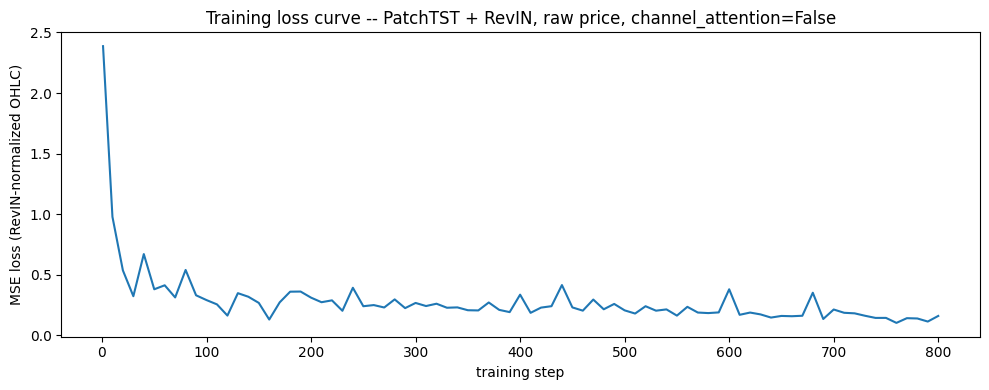

In [10]:
# -- Training loss curve ------------------------------------------
steps, losses = zip(*loss_history)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, losses)
ax.set_xlabel('training step')
ax.set_ylabel('MSE loss (RevIN-normalized OHLC)')
ax.set_title(f'Training loss curve -- PatchTST + RevIN, raw price, channel_attention={CHANNEL_ATTENTION}')
plt.tight_layout()
plt.show()

## Evaluation

Same OHLC MAE/RMSE methodology as every other notebook in this family (directly
comparable -- no `reconstruct_prices` step needed here since the model's denormalized
output is already absolute price). Directional accuracy uses the same close_0-anchored
convention as the rest of this project (`close_0` = the last known context bar's close).

**The key diagnostic from this experiment's motivation**: what fraction of test windows
have all 3 predicted horizon bars agree on direction (the same "coherence" check
`evaluate.py`'s `patchtst_confidence_scores` uses to gate trades) -- the return-based
variant scored **zero** out of 2397. If this framing genuinely avoids that collapse, this
number should be meaningfully above zero.

In [11]:
def mae_rmse(pred: np.ndarray, true: np.ndarray) -> tuple[float, float]:
    diff = pred - true
    return float(np.mean(np.abs(diff))), float(np.sqrt(np.mean(diff ** 2)))


test_starts_full = test_sampler.valid_starts(MAX_CONTEXT)
test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextOHLCDataset(ohlc, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)

model.eval()
all_true, all_pred, all_close0 = [], [], []
with torch.no_grad():
    for batch in test_loader:
        pv = batch['past_values'].to(DEVICE)
        fv = batch['future_values'].to(DEVICE)
        pred_norm = model(pv)
        pred_price = model.revin.denormalize(pred_norm)   # back to real price -- no reconstruct_prices needed
        all_true.append(fv.cpu().numpy())
        all_pred.append(pred_price.cpu().numpy())
        all_close0.append(pv[:, -1, OHLC_COLS.index('close')].cpu().numpy())   # last context bar's real close

true_ohlc = np.concatenate(all_true)     # (n, 3, 4) real [open,high,low,close]
pred_ohlc = np.concatenate(all_pred)     # (n, 3, 4) predicted
close_0 = np.concatenate(all_close0)     # (n,)
n = len(true_ohlc)
print(f'Evaluated on {n:,} fixed-context (70-bar) test windows')

ohlc_mae, ohlc_rmse = mae_rmse(pred_ohlc, true_ohlc)

true_close_ret = np.sign(true_ohlc[:, :, 3] - close_0[:, None])
pred_close_ret = np.sign(pred_ohlc[:, :, 3] - close_0[:, None])
dir_acc = (true_close_ret == pred_close_ret).mean(axis=0)

# Coherence check -- the diagnostic this whole experiment is testing (see markdown above).
coherent_up = (pred_close_ret > 0).all(axis=1)
coherent_down = (pred_close_ret < 0).all(axis=1)
coherence_rate = (coherent_up | coherent_down).mean()

print(f'\n=== PatchTST + RevIN, raw price, channel_attention={CHANNEL_ATTENTION}, context=70 (fixed) ===')
print(f'  OHLC MAE / RMSE       : {ohlc_mae:.4f} / {ohlc_rmse:.4f}')
print(f'  dir acc per bar       : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')
print(f'  coherence rate        : {coherence_rate:.4f}  ({int((coherent_up | coherent_down).sum())} / {n} windows -- '
      f'return-based variant scored 0/2397 on this exact check)')
print(f'  std(pred)/std(true)   : {(pred_ohlc.std() / true_ohlc.std()):.4f}  (near 0 = flat/collapsed predictions)')

print('\n=== For comparison: return-based price-only variant (fused head, no volume) ===')
print('  channel_attention=False: OHLC MAE/RMSE 2.27/3.34, coherence 0/2397')
print('  channel_attention=True : OHLC MAE/RMSE 1.87/3.05, coherence 0/2397')

print('\n=== For comparison: steven/outputs/metrics.json, original hand-rolled PatchTST, "long" bucket ===')
print('  OHLC MAE/RMSE 11.21/13.76')

Evaluated on 2,397 fixed-context (70-bar) test windows

=== PatchTST + RevIN, raw price, channel_attention=False, context=70 (fixed) ===
  OHLC MAE / RMSE       : 1.8161 / 3.0468
  dir acc per bar       : 0.5277 / 0.5369 / 0.5486
  coherence rate        : 0.9566  (2293 / 2397 windows -- return-based variant scored 0/2397 on this exact check)
  std(pred)/std(true)   : 1.0034  (near 0 = flat/collapsed predictions)

=== For comparison: return-based price-only variant (fused head, no volume) ===
  channel_attention=False: OHLC MAE/RMSE 2.27/3.34, coherence 0/2397
  channel_attention=True : OHLC MAE/RMSE 1.87/3.05, coherence 0/2397

=== For comparison: steven/outputs/metrics.json, original hand-rolled PatchTST, "long" bucket ===
  OHLC MAE/RMSE 11.21/13.76


## Caveats and recommended next steps

- **One seed, one trained model.** Rerun with a different `SEED` before trusting any
  specific delta.
- **`evaluate.py` does NOT support this checkpoint.** Its saved config has no
  `channel_attention`-only shape and a different target (`'target': 'raw_ohlc_revin'`) --
  `detect_patchtst_arch`/`build_patchtst_model`/`run_patchtst` would all need a new arch
  branch. Per instruction, this notebook stays self-contained (no `.py` changes) rather
  than wiring this into the shared `evaluate.py` pipeline.
- **No backtest yet** -- deferred, same as every other notebook in this family, until an
  architecture is picked. The coherence-rate check above is a cheap proxy for whether a
  real backtest would even have any eligible trades, not a substitute for one.
- **RevIN's own limitation**: it normalizes using each window's own trailing mean/std,
  which assumes the near-term future shares the recent local distribution. That's a
  reasonable assumption for hourly SPY over 3 bars, but it's an assumption, not a
  guarantee -- a genuine regime shift within the horizon would violate it.
- **Fixed context (70 bars) vs. steven's variable-length curriculum**, same simplification
  as every other notebook in this family.
- **No output bounding at all** (see intro markdown) -- if training is unstable or the
  model is undertrained, nothing currently stops a wild RevIN-denormalized prediction the
  way `MAX_LOG_RETURN` did for the return-based variants. Worth adding a sanity clip if
  this approach looks promising enough to develop further.